# Introduction to Least Squares

## Purpose

Understand least squares as finding the best approximate fit when an exact solution is not possible.

This notebook uses a small line-fitting example to connect three ideas:

- residuals as prediction errors
- least squares as minimising the sum of squared residuals
- the matrix form used by `np.linalg.lstsq`

We will keep the example small and visual.

## Imports and helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_plot(title, xlim=(0.5, 4.5), ylim=(1.5, 4.25), figsize=(5.5, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    return fig, ax


def predict_line(x_values, slope, intercept):
    return slope * x_values + intercept


def sum_squared_errors(actual, predicted):
    residuals = actual - predicted
    return np.sum(residuals ** 2)

## A simple fitting problem

Suppose we have some points:

$$
(1, 2), (2, 2.5), (3, 3.5), (4, 3.8)
$$

They do not lie perfectly on a straight line.

But we can still ask:

> what line fits these points reasonably well?

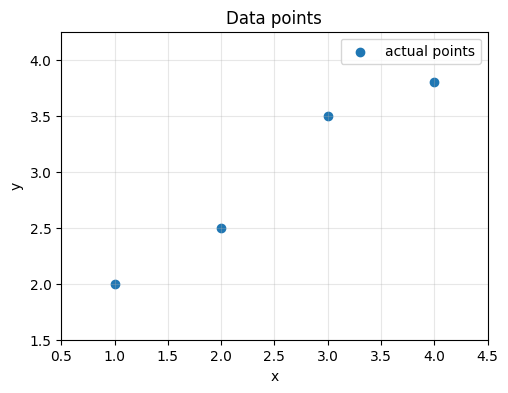

In [2]:
x = np.array([1, 2, 3, 4])
y = np.array([2.0, 2.5, 3.5, 3.8])

fig, ax = setup_plot("Data points")
ax.scatter(x, y, label="actual points")
ax.legend()
plt.show()

## A line model

A straight line has the form:

$$
y = mx + c
$$

where $m$ is the slope and $c$ is the intercept.

For a given $m$ and $c$, we can predict a y-value for every x-value.

In [3]:
first_m = 0.7
first_c = 1.2

first_predicted_y = predict_line(x, first_m, first_c)

print("actual y:   ", y)
print("predicted y:", first_predicted_y)

actual y:    [2.  2.5 3.5 3.8]
predicted y: [1.9 2.6 3.3 4. ]


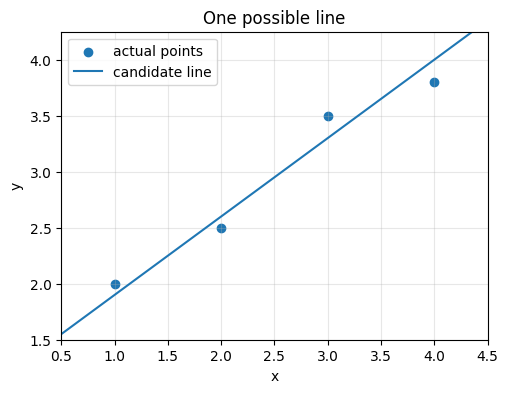

In [4]:
line_x = np.linspace(0.5, 4.5, 100)
line_y = predict_line(line_x, first_m, first_c)

fig, ax = setup_plot("One possible line")
ax.scatter(x, y, label="actual points")
ax.plot(line_x, line_y, label="candidate line")
ax.legend()
plt.show()

## Residuals

A residual is the difference between an actual value and a predicted value.

$$
\text{residual} = y - \hat{y}
$$

Here, $\hat{y}$ is the predicted value.

These are vertical residuals because this model predicts a y-value from each x-value.

In [5]:
first_residuals = y - first_predicted_y

print("residuals:", first_residuals)

residuals: [ 0.1 -0.1  0.2 -0.2]


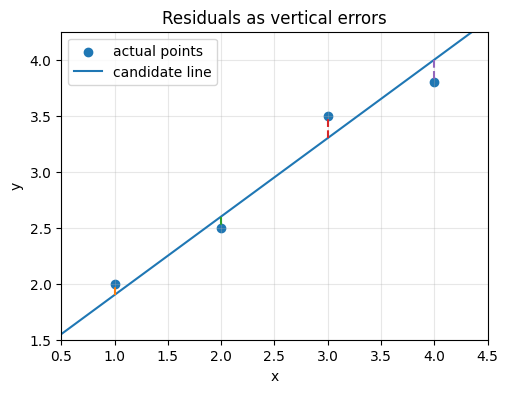

In [6]:
fig, ax = setup_plot("Residuals as vertical errors")
ax.scatter(x, y, label="actual points")
ax.plot(line_x, line_y, label="candidate line")

for xi, actual, predicted in zip(x, y, first_predicted_y):
    ax.plot([xi, xi], [predicted, actual], linestyle="--", linewidth=1.5)

ax.legend()
plt.show()

The dashed lines show the vertical errors between the candidate line and the data points.

Least squares gives a precise meaning to the word **best**:

> the best line is the line with the smallest sum of squared residuals.

## Why square the residuals?

Residuals can be positive or negative.

If we simply add them, they can cancel out.

So least squares uses the sum of squared residuals:

$$
\sum_i (y_i - \hat{y}_i)^2
$$

Squaring does two useful things:

- negative and positive errors both become positive
- larger errors are penalised more heavily

In [7]:
first_ssr = sum_squared_errors(y, first_predicted_y)

print("candidate line sum of squared residuals:", first_ssr)

candidate line sum of squared residuals: 0.10000000000000009


## Let NumPy find the least-squares line

We will use `np.polyfit` first as a convenient way to find the best line.

Then we will look at the matrix version of the same idea.

In [8]:
best_m, best_c = np.polyfit(x, y, deg=1)

print("best slope:    ", best_m)
print("best intercept:", best_c)

best slope:     0.6399999999999998
best intercept: 1.3500000000000008


In [9]:
best_predicted_y = predict_line(x, best_m, best_c)
best_residuals = y - best_predicted_y
best_ssr = sum_squared_errors(y, best_predicted_y)

print("best predicted y:", best_predicted_y)
print("best residuals:  ", best_residuals)
print("best sum of squared residuals:", best_ssr)
print("candidate line sum of squared residuals:", first_ssr)

best predicted y: [1.99 2.63 3.27 3.91]
best residuals:   [ 0.01 -0.13  0.23 -0.11]
best sum of squared residuals: 0.08199999999999993
candidate line sum of squared residuals: 0.10000000000000009


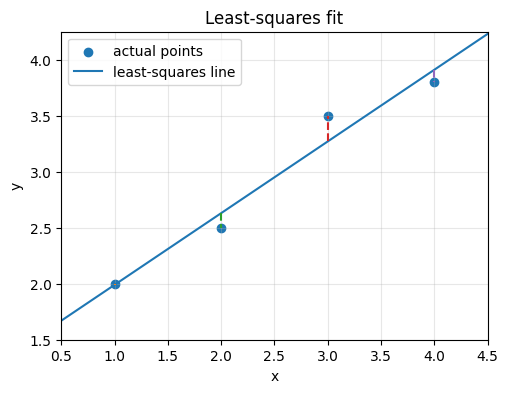

In [10]:
best_line_y = predict_line(line_x, best_m, best_c)

fig, ax = setup_plot("Least-squares fit")
ax.scatter(x, y, label="actual points")
ax.plot(line_x, best_line_y, label="least-squares line")

for xi, actual, predicted in zip(x, y, best_predicted_y):
    ax.plot([xi, xi], [predicted, actual], linestyle="--", linewidth=1.5)

ax.legend()
plt.show()

The least-squares line has a smaller sum of squared residuals than the earlier candidate line.

That is what **best fit** means in this notebook.

## Matrix view of the same problem

The line equation:

$$
y = mx + c
$$

can be written as a matrix problem.

For the x-values $1, 2, 3, 4$, build a matrix:

$$
X =
\begin{bmatrix}
1 & 1 \\
2 & 1 \\
3 & 1 \\
4 & 1
\end{bmatrix}
$$

The first column contains the x-values.

The second column contains ones for the intercept.

In [11]:
X = np.column_stack([x, np.ones_like(x)])

print(X)

[[1 1]
 [2 1]
 [3 1]
 [4 1]]


The unknown parameters are:

$$
\beta =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

Then the predictions are:

$$
X\beta
$$

In [12]:
beta = np.array([best_m, best_c])

predictions_from_matrix = X @ beta

print("X @ beta:        ", predictions_from_matrix)
print("best predicted y:", best_predicted_y)

X @ beta:         [1.99 2.63 3.27 3.91]
best predicted y: [1.99 2.63 3.27 3.91]


## Why this is not usually an exact solve

There are four data points, so the line would need to satisfy four equations:

$$
\begin{aligned}
m \cdot 1 + c &\approx 2.0 \\
m \cdot 2 + c &\approx 2.5 \\
m \cdot 3 + c &\approx 3.5 \\
m \cdot 4 + c &\approx 3.8
\end{aligned}
$$

But there are only two unknowns: $m$ and $c$.

Because the points do not lie perfectly on a straight line, there is usually no exact solution.

So instead of solving $X\beta = y$ exactly, least squares finds the $\beta$ that gets as close as possible.

## Solving with `np.linalg.lstsq`

NumPy can solve the matrix least-squares problem directly:

$$
X\beta \approx y
$$

This means:

> find the best parameter vector $\beta$ when $X\beta = y$ cannot usually be satisfied exactly.

In [13]:
beta_lstsq, residual_sums, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)

print("beta from lstsq:", beta_lstsq)
print("slope:          ", beta_lstsq[0])
print("intercept:      ", beta_lstsq[1])

beta from lstsq: [0.64 1.35]
slope:           0.6400000000000001
intercept:       1.3499999999999994


The result matches the line fitted earlier.

This is the least-squares solution written in matrix form.

## Connection back to projection

In the projection notebook, we split a vector into:

$$
\text{parallel component} + \text{perpendicular component}
$$

Least squares has a similar flavour.

We are not going to fully unpack that geometry here, but the important idea is this:

> least squares finds the closest achievable prediction.

The model can only produce predictions of the form $X\beta$.

Least squares chooses the achievable prediction closest to the actual values, leaving a residual error that the model cannot explain.

## Summary

Least squares is useful when an exact fit is not possible.

In this notebook, we fitted a line to a small set of points.

A residual is the prediction error:

$$
\text{residual} = y - \hat{y}
$$

Least squares chooses the line that minimises:

$$
\sum_i (y_i - \hat{y}_i)^2
$$

The key takeaways are:

- residuals are the differences between actual and predicted values
- least squares minimises the sum of squared residuals
- a line $y = mx + c$ can be written as a matrix problem
- `np.linalg.lstsq` solves the matrix least-squares problem directly
- geometrically, least squares is connected to finding the closest achievable prediction

The main idea is:

> when exact fitting is impossible, least squares gives us a principled best approximate fit.